In [43]:
import pandas as pd
import matplotlib.pyplot as plt

path = "../datasets/greengrid_v2_2/raw_data/"

In [11]:
def cat_clean(data: pd.DataFrame):
    """Cleaning inconsistency in categorical data"""
    columns = list(data.columns)
    for column in columns:
        if data[column].dtypes == "object":
           data[column] = [i.upper().strip() for i in data[column].astype(str)]

In [30]:
def cat_flag(data: pd.DataFrame):
    """Flagging inconsistency in categorical data"""
    columns = list(data.columns)
    for column in columns:
        if data[column].dtypes == "object":
            a = list(
                    set(
                        [i.upper().strip() for i in list(data[column].unique().astype(str))]
                        )
                )
            b = list(data[column].unique())
            if len(a) == len(b):
                print(column, "->", "Consistent")
            else:
                print(column, "->", "Inconsistent")

## Asset

In [31]:
assets = path + "asset_registry_raw.csv"

df_assets = pd.read_csv(assets)

df_assets

,asset_id,asset_name,technology,region,grid_node,capacity_mw,commission_date,asset_status,source_system
0,SOL-N01,North Solar One,Solar PV,North,NORTH_A,180,2023-06-01,Operational,ASSET_REGISTRY
1,SOL-N02,North Solar Two,Solar PV,North,NORTH_A,140,2024-03-15,Operational,ASSET_REGISTRY
2,WND-N01,North Wind One,WIND,North,NORTH_B,220,2022-10-01,Operational,ASSET_REGISTRY
3,SOL-C01,Central Solar One,Solar PV,Central,CENTRAL_A,160,2023-01-10,Operational,ASSET_REGISTRY
4,SOL-C02,Central Solar Two,Solar PV,Central,CENTRAL_A,110,2024-07-01,Operational,ASSET_REGISTRY
5,WND-C01,Central Wind One,wind,central,CENTRAL_B,180,2022-05-20,Operational,ASSET_REGISTRY


In [32]:
cat_clean(df_assets)
cat_flag(df_assets)

asset_id -> Consistent
asset_name -> Consistent
technology -> Consistent
region -> Consistent
grid_node -> Consistent
commission_date -> Consistent
asset_status -> Consistent
source_system -> Consistent


In [33]:
df_assets = df_assets.drop_duplicates()
df_assets.duplicated().sum()

np.int64(0)

In [34]:
df_assets = df_assets.dropna()
df_assets.isnull().sum()

asset_id           0
asset_name         0
technology         0
region             0
grid_node          0
capacity_mw        0
commission_date    0
asset_status       0
source_system      0
dtype: int64

## BESS

In [103]:
bess = path + "bess_operations_raw.csv"

df_bess = pd.read_csv(bess)

df_bess.head()

,timestamp,region,battery_power_capacity_mw,battery_energy_capacity_mwh,charge_mwh,discharge_mwh,source_system,record_status
0,2025-01-01 00:00:00,North,50,200,0.0,0.0,BESS_CONTROLLER,VALID
1,2025-01-01 00:00:00,Central,50,200,0.0,0.0,BESS_CONTROLLER,VALID
2,2025-01-01 01:00:00,North,50,200,0.0,0.0,BESS_CONTROLLER,VALID
3,2025-01-01 01:00:00,Central,50,200,0.0,0.0,BESS_CONTROLLER,VALID
4,2025-01-01 02:00:00,North,50,200,0.0,0.0,BESS_CONTROLLER,VALID


In [104]:
cat_clean(df_bess)
cat_flag(df_bess)

timestamp -> Consistent
region -> Consistent
source_system -> Consistent
record_status -> Consistent


In [105]:
df_bess = df_bess.drop_duplicates()
df_bess.duplicated().sum()

np.int64(0)

In [106]:
df_bess = df_bess.dropna()
df_bess.isnull().sum()

timestamp                      0
region                         0
battery_power_capacity_mw      0
battery_energy_capacity_mwh    0
charge_mwh                     0
discharge_mwh                  0
source_system                  0
record_status                  0
dtype: int64

In [107]:
df_bess.describe()

,battery_power_capacity_mw,battery_energy_capacity_mwh,charge_mwh,discharge_mwh
count,17469.0,17469.0,17469.000000,17469.000000
mean,50.0,200.0,2.765242,2.212873
std,0.0,0.0,18.105486,8.571690
min,50.0,200.0,-10.000000,0.000000
25%,50.0,200.0,0.000000,0.000000
50%,50.0,200.0,0.000000,0.000000
75%,50.0,200.0,0.000000,0.000000
max,50.0,200.0,999.000000,37.500000


In [108]:
df_bess[df_bess["charge_mwh"] >= 0][df_bess["charge_mwh"] != 999].describe()

C:\Users\User\AppData\Local\Temp\ipykernel_2184\2627907241.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_bess[df_bess["charge_mwh"] >= 0][df_bess["charge_mwh"] != 999].describe()


,battery_power_capacity_mw,battery_energy_capacity_mwh,charge_mwh,discharge_mwh
count,17461.0,17461.0,17461.000000,17461.000000
mean,50.0,200.0,2.539947,2.213887
std,0.0,0.0,10.024850,8.573523
min,50.0,200.0,0.000000,0.000000
25%,50.0,200.0,0.000000,0.000000
50%,50.0,200.0,0.000000,0.000000
75%,50.0,200.0,0.000000,0.000000
max,50.0,200.0,50.000000,37.500000


Menggunakan metode **Capping**, di mana nilai negatif diganti menjadi 0 dan 999 diganti menjadi 50

In [109]:
df_bess.loc[df_bess["charge_mwh"] < 0, "charge_mwh"] = 0
df_bess.loc[df_bess["charge_mwh"] == 999, "charge_mwh"] = 50

In [110]:
df_bess.describe()

,battery_power_capacity_mw,battery_energy_capacity_mwh,charge_mwh,discharge_mwh
count,17469.0,17469.0,17469.000000,17469.000000
mean,50.0,200.0,2.550232,2.212873
std,0.0,0.0,10.048321,8.571690
min,50.0,200.0,0.000000,0.000000
25%,50.0,200.0,0.000000,0.000000
50%,50.0,200.0,0.000000,0.000000
75%,50.0,200.0,0.000000,0.000000
max,50.0,200.0,50.000000,37.500000


## Dispatch

In [111]:
dispatch = path + "dispatch_curtailment_log_raw.csv"

df_dispatch = pd.read_csv(dispatch)

df_dispatch.head()

,event_id,region,start_time,end_time,reason,operator_action,source_system,record_status
0,CE-00001,North,2025-01-11 12:00:00,2025-01-11 12:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID
1,CE-00002,North,2025-01-25 11:00:00,2025-01-25 13:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID
2,CE-00003,North,2025-02-01 11:00:00,2025-02-01 11:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID
3,CE-00004,North,2025-02-02 10:00:00,2025-02-02 10:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID
4,CE-00005,North,2025-02-02 14:00:00,2025-02-02 14:00:00,storage_constraint,Dispatch down renewable output,DISPATCH_LOG,VALID


In [112]:
cat_clean(df_dispatch)
cat_flag(df_dispatch)

event_id -> Consistent
region -> Consistent
start_time -> Consistent
end_time -> Consistent
reason -> Consistent
operator_action -> Consistent
source_system -> Consistent
record_status -> Consistent


In [113]:
df_dispatch = df_dispatch.drop_duplicates()
df_dispatch.duplicated().sum()

np.int64(0)

In [114]:
df_dispatch = df_dispatch.dropna()
df_dispatch.isnull().sum()

event_id           0
region             0
start_time         0
end_time           0
reason             0
operator_action    0
source_system      0
record_status      0
dtype: int64

## EMS

In [115]:
ems = path + "ems_operations_raw.csv"
df_ems = pd.read_csv(ems)

df_ems.head()

,timestamp,total_demand_mwh,north_export_limit_mw,central_export_limit_mw,source_system,demand_unit,record_status
0,01/01/2025 00:00,269.595543,80.0,220.0,EMS,MWh,VALID
1,2025-01-01 01:00:00,304.452778,80.0,220.0,EMS,MWh,VALID
2,2025-01-01 02:00:00,285.878869,80.0,220.0,EMS,MWh,VALID
3,2025-01-01 03:00:00,299.750572,80.0,220.0,EMS,MWh,VALID
4,2025-01-01 04:00:00,321.041077,80.0,220.0,EMS,MWh,VALID


In [116]:
cat_clean(df_ems)
cat_flag(df_ems)

timestamp -> Consistent
source_system -> Consistent
demand_unit -> Consistent
record_status -> Consistent


In [117]:
df_ems.loc[df_ems["demand_unit"] == "MW", "demand_unit"] = "MWH"

In [118]:
df_ems = df_ems.drop_duplicates()
df_ems.duplicated().sum()

np.int64(0)

In [119]:
df_ems = df_ems.dropna()
df_ems.isnull().sum()

timestamp                  0
total_demand_mwh           0
north_export_limit_mw      0
central_export_limit_mw    0
source_system              0
demand_unit                0
record_status              0
dtype: int64

In [120]:
df_ems.describe()

,total_demand_mwh,north_export_limit_mw,central_export_limit_mw
count,8743.000000,8743.000000,8743.000000
mean,366.860546,77.203706,219.505799
std,64.751542,6.927570,4.798616
min,201.609089,43.200000,158.400000
25%,317.932169,80.000000,220.000000
50%,366.193765,80.000000,220.000000
75%,411.910424,80.000000,220.000000
max,551.613558,80.000000,220.000000


## Market Price

In [121]:
market_price = path + "market_price_raw.csv"
df_market_price = pd.read_csv(market_price)

df_market_price.head()

,timestamp,market_price_usd_per_mwh,source_system,record_status
0,2025-01-01 00:00:00,52.97,MARKET_FEED,VALID
1,2025-01-01 01:00:00,55.24,MARKET_FEED,VALID
2,2025-01-01 02:00:00,63.02,MARKET_FEED,VALID
3,2025-01-01 03:00:00,54.80,MARKET_FEED,VALID
4,2025-01-01 04:00:00,63.04,MARKET_FEED,VALID


In [122]:
cat_clean(df_market_price)
cat_flag(df_market_price)

timestamp -> Consistent
source_system -> Consistent
record_status -> Consistent


In [123]:
df_market_price = df_market_price.drop_duplicates()
df_market_price.duplicated().sum()

np.int64(0)

In [124]:
df_market_price = df_market_price.dropna()
df_market_price.isnull().sum()

timestamp                   0
market_price_usd_per_mwh    0
source_system               0
record_status               0
dtype: int64

In [125]:
df_market_price.describe()

,market_price_usd_per_mwh
count,8744.000000
mean,67.826852
std,11.076892
min,-14.750000
25%,61.637500
50%,68.395000
75%,75.002500
max,95.080000


In [126]:
df_market_price[df_market_price["market_price_usd_per_mwh"] < 0]

# df_market_price.loc[df_market_price["market_price_usd_per_mwh"] < 0, "market_price_usd_per_mwh"]

,timestamp,market_price_usd_per_mwh,source_system,record_status
755,2025-02-01 11:00:00,-11.20,MARKET_FEED,VALID
1452,2025-03-02 12:00:00,-9.27,MARKET_FEED,VALID
1812,2025-03-17 12:00:00,-7.19,MARKET_FEED,VALID
1932,2025-03-22 12:00:00,-4.20,MARKET_FEED,VALID
2002,2025-03-25 10:00:00,-12.25,MARKET_FEED,VALID
...,...,...,...,...
7164,2025-10-26 12:00:00,-3.78,MARKET_FEED,VALID
7165,2025-10-26 13:00:00,-7.60,MARKET_FEED,VALID
7331,2025-11-02 11:00:00,-10.59,MARKET_FEED,VALID
7834,2025-11-23 10:00:00,-7.24,MARKET_FEED,VALID


In [131]:
df_market_price[df_market_price["market_price_usd_per_mwh"] >= 0].describe()

,market_price_usd_per_mwh
count,8670.000000
mean,68.468300
std,8.658146
min,42.990000
25%,61.792500
50%,68.515000
75%,75.060000
max,95.080000


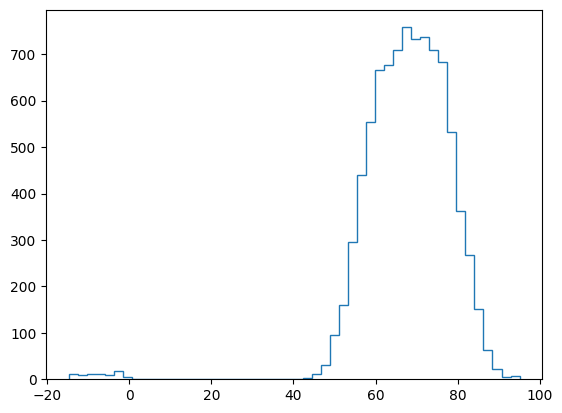

In [130]:
plt.hist(df_market_price["market_price_usd_per_mwh"], histtype="step", bins=50)
plt.show()

In [134]:
df_market_price.loc[df_market_price["market_price_usd_per_mwh"] < 0, "market_price_usd_per_mwh"] = df_market_price["market_price_usd_per_mwh"][df_market_price["market_price_usd_per_mwh"] >=0].mean()

In [135]:
df_market_price.describe()

,market_price_usd_per_mwh
count,8744.000000
mean,68.468300
std,8.621427
min,42.990000
25%,61.900000
50%,68.468300
75%,75.002500
max,95.080000


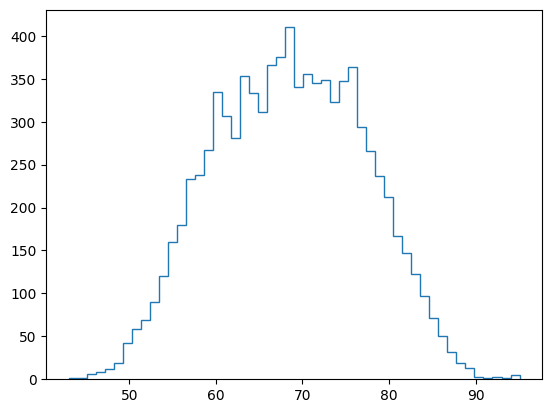

In [136]:
plt.hist(df_market_price["market_price_usd_per_mwh"], bins=50, histtype="step")
plt.show()